# YOLO11 ONNX 推理示例

本Notebook展示了如何使用YOLOv8的axmodel模型进行推理，包括预处理、模型推理、后处理（包含分布焦点损失DFL的解码），以及结果的可视化步骤。


## 1. 安装必要的库

确保您已经安装了以下Python库。如果尚未安装，可以取消注释并运行以下代码块。


In [1]:
# !pip install numpy opencv-python matplotlib

## 2. 导入库和配置参数

设置必要的参数，包括模型路径、输入图像路径、置信度阈值、非极大值抑制阈值、输入尺寸以及类别名称。


In [8]:
import axengine as axe
from axengine import axclrt_provider_name, axengine_provider_name
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass

# 配置参数
MODEL_PATH = 'yolo11n.axmodel'          # 替换为你的YOLOv8 ONNX模型路径
IMAGE_PATH = 'dog.jpg'            # 替换为你要检测的图片路径
CONFIDENCE_THRESHOLD = 0.25         # 置信度阈值
NMS_THRESHOLD = 0.45                # 非极大值抑制阈值
INPUT_SIZE = (320, 320)              # 输入尺寸
REG_MAX = 16                         # DFL的最大分布

# COCO类名（完整的列表，请根据需要补充）
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

## 3. 定义辅助数据结构和函数

定义用于存储检测对象的数据类`Object`，以及辅助函数`sigmoid`、`softmax`和`decode_distributions`。


In [3]:
@dataclass
class Object:
    bbox: list  # [x0, y0, width, height]
    label: int
    prob: float

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x, axis=-1):
    """
    稳定的Softmax实现
    """
    x = x - np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def decode_distributions(feat, reg_max=16):
    """
    解码分布焦点损失（DFL）输出
    feat: [num_bboxes, 4, reg_max] 形状的数组
    返回: [num_bboxes, 4] 解码后的距离
    """
    # 应用softmax
    prob = softmax(feat, axis=-1)  # [num_bboxes, 4, reg_max]
    # 计算期望值
    dis = np.sum(prob * np.arange(reg_max), axis=-1)  # [num_bboxes, 4]
    return dis

## 4. 定义预处理函数

读取输入图像，进行颜色空间转换、调整大小、归一化以及形状转换，最终生成模型所需的输入张量。


In [4]:
def preprocess(image_path, input_size):
    """
    读取并预处理输入图像
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"无法读取图像文件: {image_path}")
    original_shape = image.shape[:2]  # (height, width)
    # 颜色空间转换 BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # 调整大小到模型输入尺寸
    resized_image = cv2.resize(image, input_size)
    # 保持为uint8，不进行归一化
    input_tensor = np.expand_dims(resized_image, axis=0).astype(np.uint8)  # [1, 320, 320, 3]
    return input_tensor, original_shape, image

## 5. 定义后处理函数

处理模型输出，解析为检测结果，包括边界框解码（使用DFL）、置信度过滤和非极大值抑制（NMS）。


In [5]:
def postprocess(outputs, original_shape, input_size, confidence_threshold, nms_threshold, reg_max=16):
    """
    处理模型输出，解析为检测结果
    """
    # 输出head信息，根据输入尺寸调整grid_size
    heads = [
        {'output': outputs[0], 'grid_size': input_size[0] // 8, 'stride': 8},
        {'output': outputs[1], 'grid_size': input_size[0] // 16, 'stride': 16},
        {'output': outputs[2], 'grid_size': input_size[0] // 32, 'stride': 32}
    ]

    detections = []
    num_classes = 80  # COCO类数
    bbox_channels = 64  # 前64通道为bbox相关
    class_channels = 80  # 后80通道为类别分数

    for head in heads:
        output = head['output']  # [1, 144, grid, grid]
        batch_size, channels, grid_size, _ = output.shape
        stride = head['stride']

        if batch_size != 1:
            raise ValueError("当前代码仅支持batch_size=1")

        # 分割bbox和class部分
        bbox_part = output[:, :bbox_channels, :, :]  # [1, 64, grid, grid]
        class_part = output[:, bbox_channels:, :, :]  # [1, 80, grid, grid]

        # 处理bbox_part
        # 假设64 bbox channels对应于4 bbox参数（left, top, right, bottom）
        # 每个参数有reg_max=16的分布
        num_bboxes = 4  # left, top, right, bottom
        if bbox_channels != 4 * reg_max:
            raise ValueError(f"bbox_channels ({bbox_channels}) 不等于4*reg_max ({4 * reg_max})")

        # Reshape bbox_part to [1, 4, reg_max, grid_size, grid_size]
        bbox_part = bbox_part.reshape(batch_size, num_bboxes, reg_max, grid_size, grid_size)
        # Transpose to [1, grid_size, grid_size, 4, reg_max]
        bbox_part = bbox_part.transpose(0, 3, 4, 1, 2)
        # Reshape to [grid_size * grid_size, 4, reg_max]
        bbox_part = bbox_part.reshape(grid_size * grid_size, num_bboxes, reg_max)

        # 处理class_part
        # Reshape to [1, grid_size, grid_size, 80]
        class_part = class_part.reshape(batch_size, class_channels, grid_size * grid_size)
        class_part = class_part.transpose(0, 2, 1)  # [1, grid_size*grid_size, 80]
        # Reshape to [grid_size, grid_size, 80]
        class_part = class_part.reshape(batch_size, grid_size, grid_size, num_classes)

        # Iterate over grid cells
        for b in range(batch_size):
            for i in range(grid_size * grid_size):
                h = i // grid_size
                w = i % grid_size
                # 获取类别分数
                class_scores = class_part[b, h, w, :]  # [80]
                class_id = np.argmax(class_scores)
                class_score = class_scores[class_id]
                box_prob = sigmoid(class_score)

                if box_prob < confidence_threshold:
                    continue

                # 获取bbox参数
                bbox = bbox_part[i, :, :]  # [4, reg_max]

                # 解码bbox参数
                dis_left = decode_distributions(bbox[0, :], reg_max)
                dis_top = decode_distributions(bbox[1, :], reg_max)
                dis_right = decode_distributions(bbox[2, :], reg_max)
                dis_bottom = decode_distributions(bbox[3, :], reg_max)

                # 计算中心坐标
                pb_cx = (w + 0.5) * stride
                pb_cy = (h + 0.5) * stride

                # 计算边界框坐标
                x0 = pb_cx - dis_left * stride
                y0 = pb_cy - dis_top * stride
                x1 = pb_cx + dis_right * stride
                y1 = pb_cy + dis_bottom * stride

                # 将坐标缩放回原图
                scale_x = original_shape[1] / input_size[0]
                scale_y = original_shape[0] / input_size[1]
                x0 = np.clip(x0 * scale_x, 0, original_shape[1] - 1)
                y0 = np.clip(y0 * scale_y, 0, original_shape[0] - 1)
                x1 = np.clip(x1 * scale_x, 0, original_shape[1] - 1)
                y1 = np.clip(y1 * scale_y, 0, original_shape[0] - 1)

                # 计算宽度和高度
                width = x1 - x0
                height = y1 - y0

                # 添加到检测结果
                detections.append(Object(
                    bbox=[float(x0), float(y0), float(width), float(height)],
                    label=int(class_id),
                    prob=float(box_prob)
                ))

    # 应用非极大值抑制 (NMS)
    if len(detections) == 0:
        return []

    boxes = np.array([d.bbox for d in detections])  # [num_detections, 4]
    scores = np.array([d.prob for d in detections])  # [num_detections]
    class_ids = np.array([d.label for d in detections])  # [num_detections]

    final_detections = []

    unique_classes = np.unique(class_ids)
    for cls in unique_classes:
        idxs = np.where(class_ids == cls)[0]
        cls_boxes = boxes[idxs]
        cls_scores = scores[idxs]

        # 计算 NMS
        x1_cls = cls_boxes[:, 0]
        y1_cls = cls_boxes[:, 1]
        x2_cls = cls_boxes[:, 0] + cls_boxes[:, 2]
        y2_cls = cls_boxes[:, 1] + cls_boxes[:, 3]

        areas = (x2_cls - x1_cls) * (y2_cls - y1_cls)
        order = cls_scores.argsort()[::-1]

        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)

            if order.size == 1:
                break

            xx1 = np.maximum(x1_cls[i], x1_cls[order[1:]])
            yy1 = np.maximum(y1_cls[i], y1_cls[order[1:]])
            xx2 = np.minimum(x2_cls[i], x2_cls[order[1:]])
            yy2 = np.minimum(y2_cls[i], y2_cls[order[1:]])

            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            intersection = w * h
            iou = intersection / (areas[i] + areas[order[1:]] - intersection)

            inds = np.where(iou <= nms_threshold)[0]
            order = order[inds + 1]

        for idx in keep:
            final_detections.append({
                'bbox': cls_boxes[idx].tolist(),
                'score': float(cls_scores[idx]),
                'category_id': int(cls)
            })

    return final_detections

## 6. 定义主函数进行推理和可视化

预处理输入图像，加载模型，进行推理，后处理输出，并在图像上绘制检测结果。


In [6]:
def main():
    # 预处理
    try:
        input_tensor, original_shape, original_image = preprocess(IMAGE_PATH, INPUT_SIZE)
    except FileNotFoundError as e:
        print(e)
        return

    # 加载ONNX模型
    try:
        session = ort.InferenceSession(MODEL_PATH)
    except Exception as e:
        print(f"加载模型时出错: {e}")
        return

    # 获取模型输入名称
    input_name = session.get_inputs()[0].name

    # 获取模型输出
    output_names = [output.name for output in session.get_outputs()]

    # 推理
    try:
        outputs = session.run(output_names, {input_name: input_tensor})
    except Exception as e:
        print(f"推理时出错: {e}")
        return

    # 后处理
    try:
        detections = postprocess(
            outputs,
            original_shape,
            INPUT_SIZE,
            CONFIDENCE_THRESHOLD,
            NMS_THRESHOLD,
            reg_max=REG_MAX
        )
    except Exception as e:
        print(f"后处理时出错: {e}")
        return

    # 可视化结果
    for det in detections:
        bbox = det['bbox']
        score = det['score']
        class_id = det['category_id']
        if class_id >= len(COCO_CLASSES):
            label = f"cls{class_id}: {score:.2f}"
        else:
            label = f"{COCO_CLASSES[class_id]}: {score:.2f}"
        x, y, w, h = map(int, bbox)
        cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(original_image, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 显示结果
    plt.figure(figsize=(12, 8))
    plt.imshow(original_image)
    plt.axis('off')
    plt.title('Detections')
    plt.show()

## 7. 运行主函数

执行主函数，进行推理和可视化检测结果。


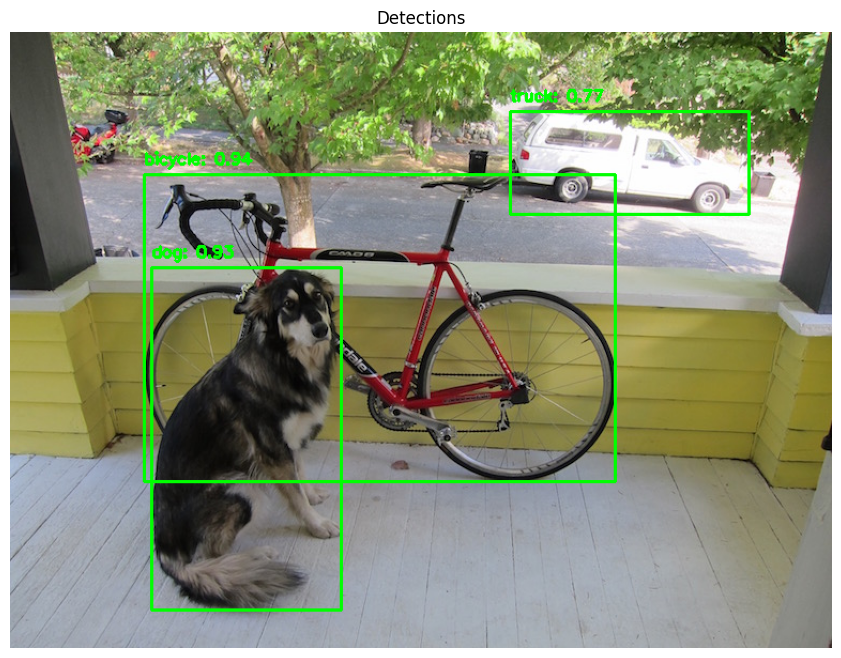

In [9]:
if __name__ == '__main__':
    main()